**Analysis of Alveolar Type II Cell Transcriptional States in Lethal COVID-19 Lung Biopsies**

by Ashley Ramsawhook, PhD.

This work is an independent analysis of the Alveolar Type II (AT2) cell transcriptional state in lethal COVID-19 lung biopsies taken from Melms *et al*, 2021 (https://doi.org/10.1038/s41586-021-03569-1). While this notebook reproduces and modifies the pre-processing steps of the raw data performed by the authors, the exploration, analysis, deductions and conclusion are independent and self-directed. The agentic Large Language Model (LLM), Claude Sonnet 5.0 (Anthropic) was utilised for code debugging, statistical methodology discussions and literature dataset navigation. All code and markdown were written by myself.



**The Dataset**

The Melms *et al*, 2021 dataset consisted of lung biopsies extracted from 7 healthy donors and 19 COVID patients harvested post-mortem and sequencing libraries were prepared from single nuclei suspensions. Only one biopsy was harvested per donor, making the terms “Sample” and “Donor” synonymous for this dataset. Ambient RNA and debris contamination had been excluded from raw counts by the authors using CELL BENDER prior to publication of the dataset.   

**External Resources for Annotation**

A curated list of human ribosomal genes was acquired from the Broad Institute's software repository: http://software.broadinstitute.org/gsea/msigdb/download_geneset.jsp?geneSetName=KEGG_RIBOSOME&fileType=txt

**Installing Necessary Libraries and Dependencies**

In [ ]:
%pip install scanpy

In [ ]:
%pip install scvi-tools

In [3]:
%pip install scikit-misc

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
! pip install leidenalg


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
! pip install gseapy

In [ ]:
! pip install celltypist --break-system-packages

In [ ]:
! pip install pydeseq2 

**Import the Necessary Libraries**

In [1]:
import pandas as pd
import numpy as np
import os
import scipy
import glob
from pathlib import Path
import seaborn as sns
from scipy.sparse import csr_matrix, issparse
import scanpy as sc
import scvi
import matplotlib.pyplot as plt
import gseapy as gp
from scipy import stats
import celltypist
from celltypist import models
import requests
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

W0920 10:00:58.610000 24760 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
e:\New virtual environment\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\New virtual environment\.venv-1\Lib\site-packages\celltypist\classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


**Setting the File Paths for Reading-in and Saving Data** 

In [2]:
from pathlib import Path

In [3]:
#Setting the input data path which contains the raw counts files
DATA_DIR = Path("E:/New Python/scRNA-seq/Tutorial/Covid scRNA-seq lung atlas/unzipped raw counts")
files = list(DATA_DIR.glob("*.csv"))

In [4]:
#Setting the output path for saving models and processed files
OUTPUT_DIR = "E:/New Python/scRNA-seq/Tutorial/Covid scRNA-seq lung atlas/processed"

**Import the Curated Geneset for Ribosomal Gene Annotation**



In [5]:
#Import the Broad Institute's Ribosomal Geneset
RIBO_LIST = Path("E:/New Python/scRNA-seq/Tutorial/Covid scRNA-seq lung atlas/KEGG_RIBOSOME.v2026.1.Hs.txt" )
ribo_genes = pd.read_table(RIBO_LIST, skiprows=2, header= None)

**Exploratory Data Analysis**

Exploratory data analysis was performed on one healthy control and one lethal COVID-19 donor sample to guage dataset dimensions, data types, missing and duplicated values and to ascertain the quality control metrics for percentage mitochondiral and ribosomal gene counts, as well as genes by count and total read counts. This exploration facilitated the discernment of thresholds for dying, dead and potential doublet exclusion prior to their application to the full 26 sample dataset.   

In [13]:
#Read-in the first healthy donor file to guage dataframe dimensions
#Note that  Scanpy reads dataframes in a Cell x Gene configuration, therefore the raw datasets require transposition
control_1 = sc.read(files[0]).T
control_1 

AnnData object with n_obs × n_vars = 6099 × 34546
    layers: None (.X)

In [ ]:
#View Observations
control_1.obs

In [ ]:
#View features
control_1.var

In [ ]:
#View the counts data
control_1.X

The first donor sample contained 6099 nuclei and 34546 genes. Nuclei were annotated with bar-codes from the 10X genomics bead library and genes were annotated with human gene symbols. Total read counts were stored in array format.  

**Cell and Gene Filtering**

To reduce the dimensions of the dataset prior to doublet removal, genes with a coverage of less than 10 nuclei were excluded to prevent the SCVI “SOLO” model from training on dead cells or debris during doublet classification.   


In [17]:
#Only keep genes that are found in atleast 10 of the cells
sc.pp.filter_genes(control_1, min_cells= 10)

In [18]:
#Check to confirm gene counts have decreased
control_1

AnnData object with n_obs × n_vars = 6099 × 19896
    var: 'n_cells'
    layers: None (.X)

This decreased the number of genes to 19896. Since exploratory data analysis is being performed on a single donor sample, the dataset can be filtered to include only the top 2000 variable genes to reduce the dimensions for doublet detection without the loss of cell marker signals. 

In [19]:
#Filter the top 2000 highly variable genes between the cells from this sample
sc.pp.highly_variable_genes(control_1, n_top_genes= 2000, subset=True, flavor= "seurat_v3")

**Doublet Detection**

SCVI tools "SOLO" model from Seurat version 3 using the variation autoencoder generative deep learning architecture was used to detect doublets based on unique cell marker expression, utilising onboard GPU acceleration.

In [ ]:
#Instantiate and train the model
scvi.model.SCVI.setup_anndata(control_1)
vae= scvi.model.SCVI(control_1)
vae.train(accelerator= "gpu", enable_checkpointing= False) 

In [ ]:
#Train the solo model which detects doublets
solo = scvi.external.SOLO.from_scvi_model(vae)
solo.train(accelerator= "gpu", enable_checkpointing= False) 

In [22]:
#Obtain the predictions from the solo model
df =solo.predict()
df["prediction"] = solo.predict(soft= False)
df

,doublet,singlet,prediction
TAGGTACCATGGCCAC-1_1,0.889824,0.110176,doublet
ATTCACTGTAACAGGC-1_1,0.826009,0.173991,doublet
TAACTTCCAACCACGC-1_1,0.609513,0.390487,doublet
TTGGGTACACGACAAG-1_1,0.917890,0.082110,doublet
AGGCCACAGAGTCACG-1_1,0.772064,0.227936,doublet
...,...,...,...
CGCCATTGTTTGCCGG-1_1,0.007213,0.992787,singlet
CACTGGGGTCTACGTA-1_1,0.001611,0.998389,singlet
CATACTTGTAGAGGAA-1_1,0.007019,0.992981,singlet
TTTGGTTTCCACGGAC-1_1,0.000715,0.999285,singlet


In [23]:
#Count the number of doublets and singlets using a frequency table
df.groupby("prediction").count()

,doublet,singlet
prediction,,
doublet,1137,1137
singlet,4962,4962


The vast majority of cells were singlets (4703) with a sizeable number of doublets (1396). To limit exclusion of a large subset of the cells, the difference between singlets and doublets was calculated and plotted to guage the doublet distribution.

In [24]:
#Calculate the difference between the doublet and singlets
df["Diff"] = df.doublet - df.singlet
df

,doublet,singlet,prediction,Diff
TAGGTACCATGGCCAC-1_1,0.889824,0.110176,doublet,0.779648
ATTCACTGTAACAGGC-1_1,0.826009,0.173991,doublet,0.652018
TAACTTCCAACCACGC-1_1,0.609513,0.390487,doublet,0.219026
TTGGGTACACGACAAG-1_1,0.917890,0.082110,doublet,0.835781
AGGCCACAGAGTCACG-1_1,0.772064,0.227936,doublet,0.544128
...,...,...,...,...
CGCCATTGTTTGCCGG-1_1,0.007213,0.992787,singlet,-0.985574
CACTGGGGTCTACGTA-1_1,0.001611,0.998389,singlet,-0.996779
CATACTTGTAGAGGAA-1_1,0.007019,0.992981,singlet,-0.985963
TTTGGTTTCCACGGAC-1_1,0.000715,0.999285,singlet,-0.998570


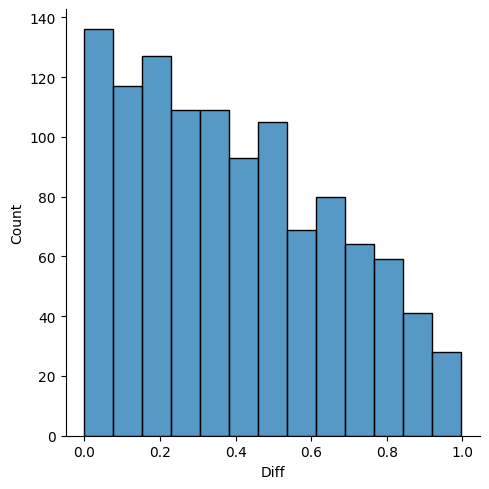

In [25]:
#Plot the distribution of doublets by difference between doublets and singlets
sns.displot(df[df.prediction == "doublet"], x = "Diff")

The histogram illustrates the decreasing doublet count with increasing disceprepancy between doublet and singlet. A marked drop in doublets is depicted between 0.1 and 0.2, suggesting true doublets may be present at discrepancies higher than 0.1. This may be an appropriate yet arbitrary threshold for filtering out potential singlets. 

In [ ]:
#Filter to include only true doublets
doublets = df[(df.prediction == "doublet") & (df["Diff"] > 0.1)]
doublets

In [27]:
#View the updated adata
control_1

AnnData object with n_obs × n_vars = 6099 × 2000
    obs: '_scvi_batch', '_scvi_labels'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', '_scvi_uuid', '_scvi_manager_uuid'
    layers: None (.X)

Owing to the “subset =True” option selection in the highly_variable_gene filtering step during preprocessing, the control_1 object has been shrunk to the size of the subset (2000 genes). Therefore the Anndata object must be re-read in form the file path.

In [28]:
#Re-read-in the first control donor file
control_1 = sc.read(files[0]).T 

Predicted doublets were annotated in the observations layer of the Anndata object.

In [ ]:
#Create a new "doublet" feature in the .obs layer of the object
control_1.obs["doublet"] = control_1.obs.index.isin(doublets.index)
control_1.obs

Filter out the cells classified as true doublets

In [30]:
#Filter out true doublets
control_1 = control_1[~control_1.obs.doublet]
control_1

View of AnnData object with n_obs × n_vars = 5133 × 34546
    obs: 'doublet'
    layers: None (.X)

Filtering out doublets reduced the dataset observations from 6099 to 4922 cells, giving a total dimension size of 4922 x 34546. To remove any dying, dead or stressed singlets mitochondrial and ribosomal genes will be annotated within the Anndata object. 

**Mitochondrial Gene Annotation**

Human mitochondrial genes possess the prefix “MT-” which can be used as a key term for identifying these genes.  A feature will be created in the .var (variables) layer to store the mitochondrial gene annotations. 


In [ ]:
#Check for mitochondiral genes -find all genes that start with "MT-""
control_1.var["MT"] = control_1.var.index.str.startswith("MT-")
control_1.var["MT"]

**Ribosomal Gene Annotation**

The Broad Institute’s curated list of ribosomal genes was used as a reference to annotate the ribosomal genes in this dataset.

In [ ]:
#Display the ribosomal gene list
ribo_genes

Create a new feature in the variables layer of the Anndata object to annotate the 88 ribosomal genes. 

In [ ]:
#Create ribo feature 
control_1.var["ribo"] = control_1.var_names.isin(ribo_genes[0].values)
control_1.var

**Obtaining Quality Control Metrics**

QC Metrics were obtained for percentage mitochondrial adn ribosomal counts using Scanpy


In [34]:
#Perform QC Metrics for mitochondiral and ribosomal genes in Scanpy
sc.pp.calculate_qc_metrics(control_1, qc_vars=["MT", "ribo"], percent_top=None, log1p=False, inplace=True)


In [ ]:
#Check the variables control_1.var layer
control_1.var

In [ ]:
#Sort the genes by coverage
control_1.var.sort_values("n_cells_by_counts")

The table illustrates that not all genes are expressed in every nucleus, some genes are not expressed in any nucleus.  Filter out the genes that are not expressed in a minimum of 3 nuclei.

In [37]:
#Filter out genes not expressed in a minium of 3 nuceli
sc.pp.filter_genes(control_1, min_cells= 3)

In [ ]:
#Sort genes by coverage
control_1.var.sort_values("n_cells_by_counts")

In [ ]:
#Check observations (cell barcodes)
control_1.obs.sort_values("total_counts")

**Plotting the QC metrics** 

The QC Metrics were used to remove outliers

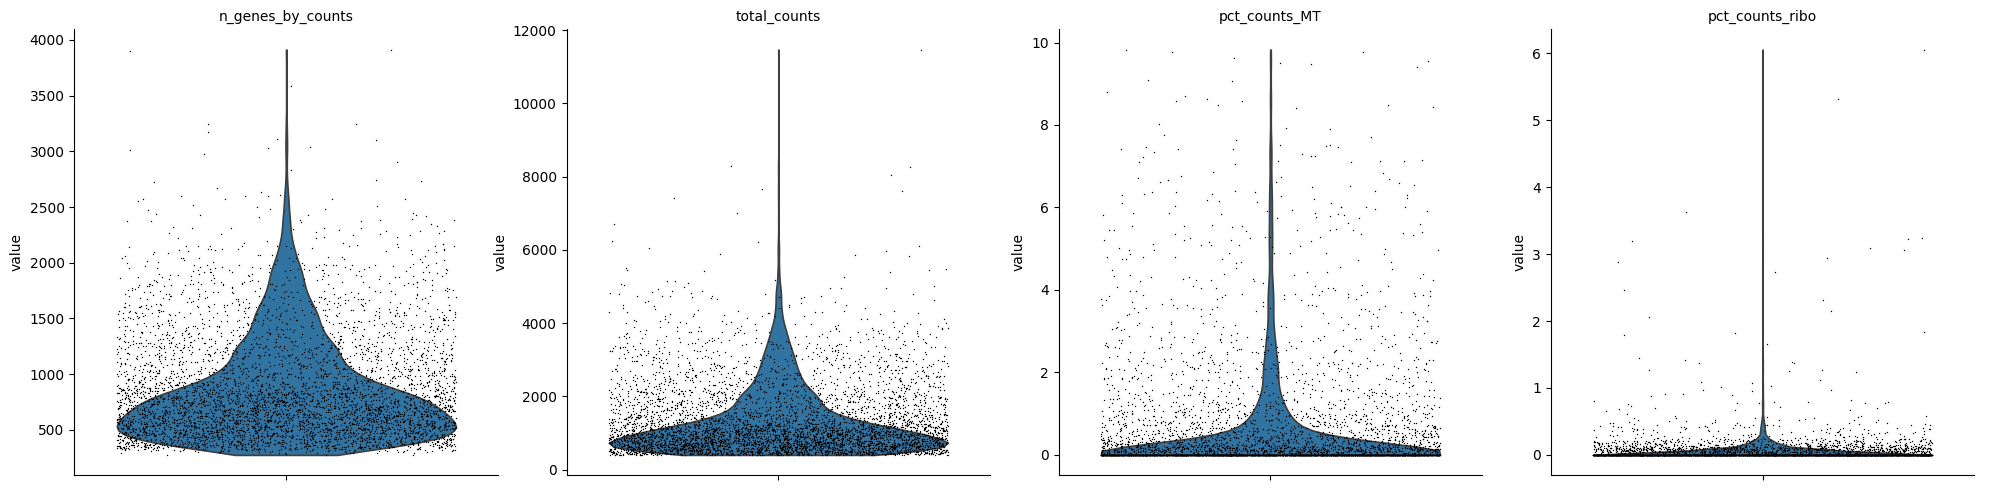

In [40]:
#Plot QC metrics
sc.pl.violin(control_1, ["n_genes_by_counts", "total_counts", "pct_counts_MT", "pct_counts_ribo"], jitter=0.4, multi_panel=True)

The violin plots illustrate that the vast majority of nuclei possess fewer than 3000 genes by count, fewer than 6000 total counts a steady cloud of nuclei between 0-10% mitochondrial counts and nuclei clustering around 0-1% ribosomal counts. **Therefore, to remove outliers, nuclei with genes_by_count greater than the 98th percentile, pct_counts_MT above 20% and pct_counts_ribo greater than 2% will be excluded from the dataset analysis.** 

**Interrogating a COVID-19 donor sample to investigate dataset dimensions and nuclei raw, mitochondrial and ribosomal percentage count distributions.** 

In [41]:
#Read in the first COVID-19 donor to guage the dimensions of the dataset 
covid_1 = sc.read(files[7]).T
covid_1

AnnData object with n_obs × n_vars = 3060 × 34546
    layers: None (.X)

In [ ]:
#View observations
covid_1.obs

In [ ]:
#View features (genes)
covid_1.var

In [ ]:
#View counts of data
covid_1.X

The first COVID-19 donor sample contained 3060 nuclei compared to the 6099 in the first control donor sample. 

**Cell and Gene Filtering**

In [45]:
#Only keep genes that are found in atleast 10 of the cells
sc.pp.filter_genes(covid_1, min_cells= 10)

In [46]:
#Check to confirm gene counts have decreased
covid_1

AnnData object with n_obs × n_vars = 3060 × 16020
    var: 'n_cells'
    layers: None (.X)

In [47]:
#Filter the top 2000 highly variable genes between the cells from this sample
sc.pp.highly_variable_genes(covid_1, n_top_genes= 2000, subset=True, flavor= "seurat_v3")

**Doublet Detection**

In [ ]:
#Instantiate and train the model
scvi.model.SCVI.setup_anndata(covid_1)
vae_1= scvi.model.SCVI(covid_1)
vae_1.train(accelerator= "gpu", enable_checkpointing= False)

In [ ]:
#Train the solo model which detects doublets
solo_1 = scvi.external.SOLO.from_scvi_model(vae_1)
solo_1.train(accelerator= "gpu", enable_checkpointing= False)

In [ ]:
#Obtain the predictions from the solo model
df_1 =solo_1.predict()
df_1["prediction"] = solo_1.predict(soft= False)
df_1

In [ ]:
#Count the number of doublets and singlets using a frequency table
df_1.groupby("prediction").count()

The COVID-19 first donor sample has 2330 singlets and 730 doublets. As with the first control sample, the doublet ditribution will be plotted to minimise the sample loss. 

In [ ]:
#Calculate the difference between the doublet and singlets
df_1["Diff"] = df_1.doublet - df_1.singlet
df_1

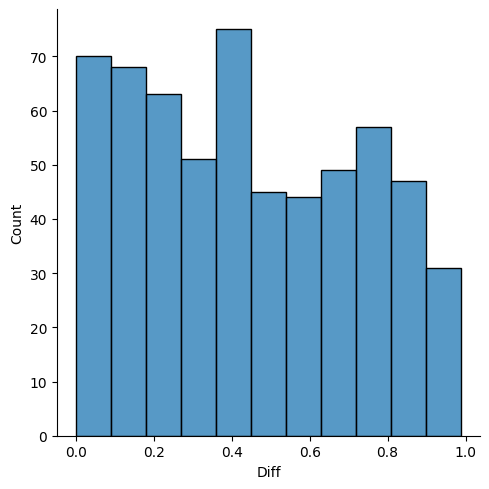

In [53]:
#Plot the distribution of doublets by difference between doublets and singlets
sns.displot(df_1[df_1.prediction == "doublet"], x = "Diff")

In [ ]:
#Filter to include only true doublets
doublets_1 = df_1[(df_1.prediction == "doublet") & (df_1["Diff"] > 0.1)]
doublets_1

In [55]:
#View the updated adata
covid_1

AnnData object with n_obs × n_vars = 3060 × 2000
    obs: '_scvi_batch', '_scvi_labels'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', '_scvi_uuid', '_scvi_manager_uuid'
    layers: None (.X)

In [56]:
#Re-read-in the first covid donor file
covid_1 = sc.read(files[7]).T 

In [ ]:
#Create new doublet feature in the .obs layer
covid_1.obs["doublet"] = covid_1.obs.index.isin(doublets_1.index)
covid_1.obs

In [ ]:
#Filter out cells labelled as true doublets
covid_1 = covid_1[~covid_1.obs.doublet]
covid_1

The first COVID-19 donor sample now contains 2415 singlets.

**Mitochondrial Gene Annotation - COVID-19**

In [ ]:
#Check for mitochondiral genes -find all genes that start with "MT-""
covid_1.var["MT"] = covid_1.var.index.str.startswith("MT-")
covid_1.var["MT"]

**Ribosomal Gene Annotation - COVID-19**

In [ ]:
#Check the full list of ribo genes 
covid_1.var["ribo"] = covid_1.var_names.isin(ribo_genes[0].values)
covid_1.var

**Obtain QC Metrics - COVID-19**

In [61]:
#Perform QC Metrics for mitochondiral and ribosomal genes in Scanpy
sc.pp.calculate_qc_metrics(covid_1, qc_vars=["MT", "ribo"], percent_top=None, log1p=False, inplace=True)


In [ ]:
#Check the variables control_1.var layer
covid_1.var

In [ ]:
#Sort genes by coverage
covid_1.var.sort_values("n_cells_by_counts")

In [64]:
#Filter out genes not expressed in a minium of 3 nuceli
sc.pp.filter_genes(covid_1, min_cells= 3)

In [ ]:
#Sort genes by coverage
covid_1.var.sort_values("n_cells_by_counts")

In [ ]:
#Check observations (cell barcodes)
covid_1.obs.sort_values("total_counts")

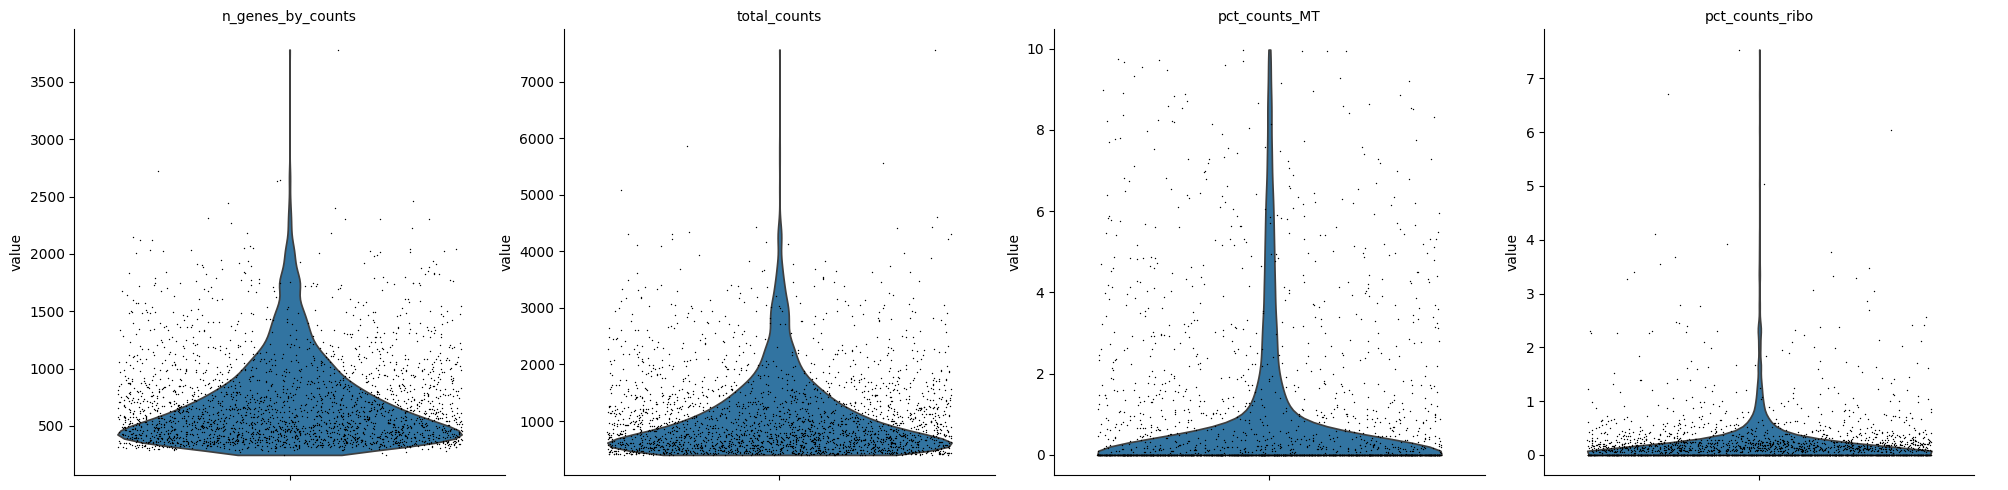

In [67]:
#Plot QC metrics
sc.pl.violin(covid_1, ["n_genes_by_counts", "total_counts", "pct_counts_MT", "pct_counts_ribo"], jitter=0.4, multi_panel=True)

The violin plots illustrate a broader distribution of nuclei by gene counts, total counts, percentage mitochondrial and ribosomal counts. The range in genes_by_counts is lower for this COVID-19 donor sample, nevertheless, the same heuristic of excluding nuclei above the 98th percentile can be applied to this sample. A greater proportion of the nuclei possess pct_counts_MT above 2% and pct_counts_ribosomal above 2%. Therefore, to sufficiently capture enough nuceli for true biological signal and statistical power while excluding genuine outliers, the threshold of excluding pct_counts_MT above 20% still stands and the threshold for excluding pct_counts_ribo will be raised from 2% to 5%, in anticipation of variation in the other 24 donor samples. These thresholds will be applied to all donor samples. 